# Early Stopping과 Checkpoint

학습을 오래 돌린다고 해서 항상 더 좋은 모델이 되는 것은 아니다.
어느 시점부터는 train 성능만 계속 좋아지고, validation 성능은 오히려 나빠질 수 있다.

그래서 실전에서는 보통
- validation 기준으로 best model을 저장하고
- 일정 기간 개선이 없으면 학습을 멈춘다.

In [10]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

## 1. Early Stopping이 필요한 이유

- train loss는 계속 감소할 수 있다.
- 하지만 validation loss는 어느 시점 이후 다시 증가할 수 있다.
- 이때 마지막 epoch 모델보다, 중간에 validation 성능이 가장 좋았던 모델이 더 중요하다.

Early Stopping은 **validation 성능이 더 이상 좋아지지 않으면 학습을 중간에 멈추는 방법** 이라고 이해하면 된다.

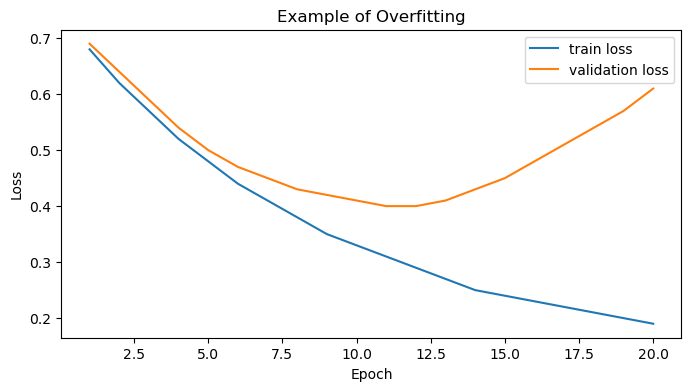

In [11]:
# 과적합 상황 예시 곡선
epochs = np.arange(1, 21)
train_loss_example = [0.68, 0.62, 0.57, 0.52, 0.48, 0.44, 0.41, 0.38, 0.35, 0.33,
                      0.31, 0.29, 0.27, 0.25, 0.24, 0.23, 0.22, 0.21, 0.20, 0.19]
val_loss_example =   [0.69, 0.64, 0.59, 0.54, 0.50, 0.47, 0.45, 0.43, 0.42, 0.41,
                      0.40, 0.40, 0.41, 0.43, 0.45, 0.48, 0.51, 0.54, 0.57, 0.61]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_example, label='train loss')
plt.plot(epochs, val_loss_example, label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Example of Overfitting')
plt.legend()
plt.show()

위 그래프처럼 train loss와 validation loss의 흐름이 갈라지기 시작하면 과적합을 의심할 수 있다.

이때 필요한 판단은 두 가지이다.

1. 어디까지 학습할 것인가
2. 어느 시점의 모델을 저장할 것인가

이에 답하는 대표적인 방법이 Early Stopping과 Checkpoint이다.

## 2. Checkpoint란 

Checkpoint는 학습 도중의 상태를 저장해두는 것이다.

가장 단순한 저장은 모델 가중치만 저장하는 방식이다.
이 경우에는 **가장 좋았던 모델로 다시 추론** 하는 데 초점을 둔다.

조금 더 일반적인 checkpoint는 다음 정보까지 함께 저장한다.

- epoch 번호
- model state_dict
- optimizer state_dict
- best validation loss

이렇게 저장하면
- 가장 좋은 모델을 다시 불러올 수 있고
- 학습이 중간에 끊겨도 이어서 진행할 수 있다.

Early Stopping과 Checkpoint는 비슷해보이지만 역할이 다르다.
- Early Stopping: 언제 멈출지 정하는 기준
- Checkpoint: 무엇을 저장할지 정하는 방식

## 3. 데이터 준비

In [12]:
# 데이터 생성
X, y = make_moons(n_samples=1000, noise=0.30, random_state=42)

# train / validation / test 분리
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# tensor 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# DataLoader
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=32,
    shuffle=False
)

print('train shape:', X_train_tensor.shape, y_train_tensor.shape)
print('val shape  :', X_val_tensor.shape, y_val_tensor.shape)
print('test shape :', X_test_tensor.shape, y_test_tensor.shape)

train shape: torch.Size([600, 2]) torch.Size([600, 1])
val shape  : torch.Size([200, 2]) torch.Size([200, 1])
test shape : torch.Size([200, 2]) torch.Size([200, 1])


## 4. 모델 정의

In [13]:
class BinaryMLP(nn.Module):
    def __init__(self, hidden_size=64, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

## 5. 학습 / 검증 함수

In [14]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()  
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()      
        logits = model(xb)         
        loss = criterion(logits, yb)
        loss.backward()            
        optimizer.step()           
        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()  
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            prob = torch.sigmoid(logits)
            pred = (prob >= 0.5).float()
            
            preds.extend(pred.flatten().tolist())
            targets.extend(yb.flatten().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)
    return avg_loss, acc

## 6. Early Stopping 없이 끝까지 학습

먼저 Early Stopping 없이 정해진 epoch까지 끝까지 학습해본다.

- 마지막 epoch 모델
- validation loss가 가장 좋았던 시점의 모델

이 둘이 서로 다를 수 있다.

즉, 끝까지 학습한 모델이 항상 가장 좋은 모델은 아니다.

In [15]:
def train_without_early_stopping(num_epochs=100, lr=0.01, seed=42):
    set_seed(seed)

    model = BinaryMLP(hidden_size=64, dropout_rate=0.3)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_loss = float('inf')
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        _, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # 마지막 epoch 모델과 별개로,
        # validation loss가 가장 좋았던 순간의 가중치를 따로 보관한다.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

    return model, history, best_epoch, best_model_state


final_model, history_no_es, best_epoch_no_es, best_model_state_no_es = train_without_early_stopping(
    num_epochs=120,
    lr=0.01,
    seed=42
)

print('best validation loss epoch:', best_epoch_no_es)
print('final epoch:', len(history_no_es['val_loss']))

best validation loss epoch: 70
final epoch: 120


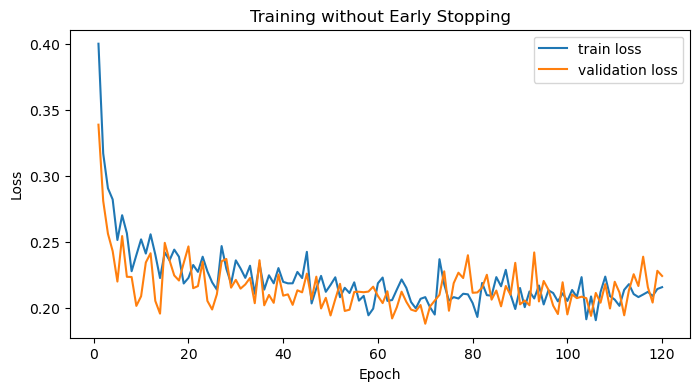

In [16]:
epochs = range(1, len(history_no_es['train_loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history_no_es['train_loss'], label='train loss')
plt.plot(epochs, history_no_es['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training without Early Stopping')
plt.legend()
plt.show()

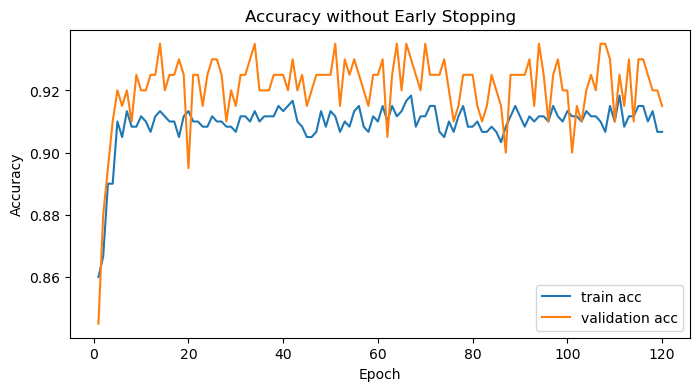

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(epochs, history_no_es['train_acc'], label='train acc')
plt.plot(epochs, history_no_es['val_acc'], label='validation acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy without Early Stopping')
plt.legend()
plt.show()

핵심은 마지막 epoch 모델과 best checkpoint 모델을 구분해서 보는 것이다.

- 마지막 epoch 모델: 그냥 가장 늦게까지 학습한 모델
- best checkpoint 모델: validation loss가 가장 좋았던 순간의 모델

실전에서는 보통 두 번째가 더 중요하다.

In [18]:
criterion = nn.BCEWithLogitsLoss()

# 1) 마지막 epoch까지 학습한 모델 성능
final_val_loss, final_val_acc = evaluate(final_model, val_loader, criterion)
final_test_loss, final_test_acc = evaluate(final_model, test_loader, criterion)

# 2) 학습 도중 validation loss가 가장 좋았던 시점의 가중치를 다시 불러온 모델 성능
best_model = BinaryMLP(hidden_size=64, dropout_rate=0.3)
best_model.load_state_dict(best_model_state_no_es)

best_val_loss, best_val_acc = evaluate(best_model, val_loader, criterion)
best_test_loss, best_test_acc = evaluate(best_model, test_loader, criterion)

print('final model')
print(f'val  loss: {final_val_loss:.4f}, val  acc: {final_val_acc:.4f}')
print(f'test loss: {final_test_loss:.4f}, test acc: {final_test_acc:.4f}')
print()
print('best checkpoint model')
print(f'val  loss: {best_val_loss:.4f}, val  acc: {best_val_acc:.4f}')
print(f'test loss: {best_test_loss:.4f}, test acc: {best_test_acc:.4f}')

final model
val  loss: 0.2243, val  acc: 0.9150
test loss: 0.2038, test acc: 0.8950

best checkpoint model
val  loss: 0.1882, val  acc: 0.9350
test loss: 0.2155, test acc: 0.9050


## 7. Early Stopping 직접 구현하기

validation loss가 좋아지지 않는 상태가 일정 횟수 이상 이어지면
학습을 멈추도록 만들어보자.

1. `patience`
- 개선이 없더라도 몇 epoch까지 기다릴지 정하는 값이다.
- 예를 들어 `patience=10`이면, 10번 연속으로 좋아지지 않을 때 멈춘다.

1. `min_delta`
- 얼마나 좋아져야 **진짜 개선** 으로 볼지 정하는 최소 변화량이다.
- 예를 들어 loss가 0.5000에서 0.4999가 되었다면, 이런 아주 작은 차이는 개선으로 보지 않을 수도 있다.

즉 Early Stopping은 **validation loss를 계속 지켜보다가, 충분한 개선이 일정 기간 없으면 중단하는 장치** 이다.

In [21]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience            # 몇 번까지 기다릴지
        self.min_delta = min_delta          # 개선으로 인정할 최소 변화량

        self.best_score = float('inf')      # 지금까지 가장 작은 val_loss
        self.counter = 0                    # 개선 없이 지난 epoch 수
        self.should_stop = False            # 학습 중단 여부

        self.best_state = None              # 가장 좋았던 모델 가중치
        self.best_epoch = 0                 # 가장 좋았던 epoch 번호

    def step(self, val_loss, model, epoch):
        # min_delta 만큼 충분히 줄어든 경우만 개선으로 판단
        if val_loss < self.best_score - self.min_delta:
            self.best_score = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch
        else:
            self.counter += 1
            # patience를 넘기면 학습을 멈추도록 표시
            if self.counter >= self.patience:
                self.should_stop = True

In [22]:
def train_with_early_stopping(num_epochs=100, lr=0.01, patience=12, min_delta=0.0, seed=42):
    set_seed(seed)

    model = BinaryMLP(hidden_size=64, dropout_rate=0.3)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    early_stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    last_epoch = 0

    for epoch in range(1, num_epochs + 1):
        last_epoch = epoch

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        _, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # 현재 epoch의 validation loss를 EarlyStopping 객체에 전달하여
        # 1) best_model 저장 여부 판단, 2) patience 넘었는지 확인
        early_stopper.step(val_loss, model, epoch)

        if early_stopper.should_stop:
            print(f'Early stopping triggered at epoch {epoch}')
            break

    # 학습이 끝난 뒤 마지막 모델이 아니라 validation loss가 가장 좋았던 시점의 가중치를 다시 적용해서 전달
    model.load_state_dict(early_stopper.best_state)

    return {
        'model': model,
        'optimizer_state_dict': optimizer.state_dict(),
        'history' : history,
        'best_epoch': early_stopper.best_epoch,
        'last_epoch': last_epoch,
        'best_val_loss' : early_stopper.best_score
    }

es_result = train_with_early_stopping(num_epochs=120, lr=0.01, patience=12, min_delta=0.005, seed=42)

es_model = es_result['model']
es_history = es_result['history']
best_epoch_es = es_result['best_epoch']
last_epoch_es = es_result['last_epoch']

print('best epoch :', best_epoch_es)
print('last epoch :', last_epoch_es)

Early stopping triggered at epoch 26
best epoch : 14
last epoch : 26


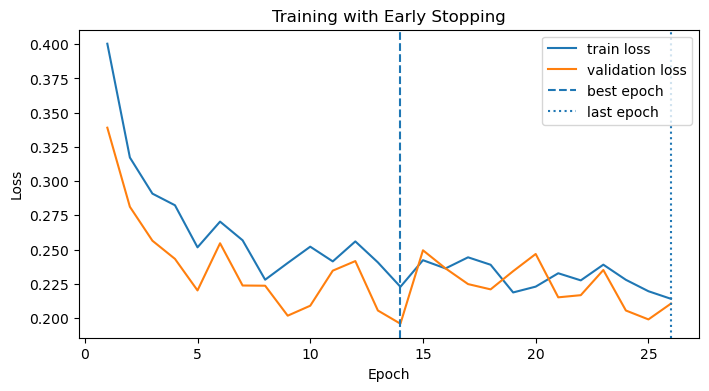

In [23]:
epochs_es = range(1, len(es_history['train_loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_es, es_history['train_loss'], label='train loss')
plt.plot(epochs_es, es_history['val_loss'], label='validation loss')
plt.axvline(best_epoch_es, linestyle='--', label='best epoch')
plt.axvline(last_epoch_es, linestyle=':', label='last epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training with Early Stopping')
plt.legend()
plt.show()

In [25]:
es_val_loss, es_val_acc = evaluate(es_model, val_loader, criterion)
es_test_loss, es_test_acc = evaluate(es_model, test_loader, criterion)

print('early stopping model')
print(f'val loss:{es_val_loss:.4f}, val acc:{es_val_acc:.4f}')
print(f'test loss:{es_test_loss:.4f}, test acc:{es_test_acc:.4f}')

early stopping model
val loss:0.1958, val acc:0.9350
test loss:0.2194, test acc:0.8850


## 8. Checkpoint 저장 예시

학습이 끝난 뒤에는 모델을 파일로 저장해두고, 나중에 다시 불러와 사용할 수 있다.

PyTorch에서는 torch.save()와 torch.load()를 이용해 모델 관련 정보를 파일로 저장하고 복원한다.

`.pt`, `.pth` : PyTorch 파일을 저장할 때 관례적으로 많이 사용하는 확장자이다. 주로 모델 가중치나 checkpoint 파일에 사용한다.

`.tar` : 여러 정보를 묶은 checkpoint 파일이라는 느낌으로 자주 사용한다. 하지만 이것도 단지 관례일 뿐이며, 꼭 .tar만 써야 하는 것은 아니다.

중요한 것은 확장자가 아니라, torch.save() 안에 어떤 객체를 넣어 저장했는가이다.

In [ ]:
# 1. 모델 가중치만 저장하기
# 이미 학습 된 모델을 나중에 다시 불러와 예측이나 평가에 사용하고 싶을 때
save_path_weights = 'best_model_weights.pth'
torch.save(es_model.state_dict(), save_path_weights)    # 각 레이어의 weight, bias 같은 학습 된 파라미터 저장
print('saved:', save_path_weights)

# 저장한 가중치는 같은 구조의 모델을 다시 만든 뒤 load_state_dict()으로 복원한다.
loaded_model = BinaryMLP(hidden_size=64, dropout_rate=0.3)
loaded_model.load_state_dict(torch.load(save_path_weights, weights_only=True))
loaded_model.eval()

loaded_test_loss, loaded_test_acc = evaluate(loaded_model, test_loader, criterion)
print(f'loaded model test acc : {loaded_test_acc:.4f}')

saved: best_model_weights.pth
loaded model test acc : 0.8850


In [28]:
# 2. 학습 재개용 checkpoint 저장
# 모델 가중치 뿐만 아니라 모델 구조 정보, optimizer 정보, 현재 epoch 등을 함께 저장

checkpoint = {
    'epoch' : es_result['last_epoch'],
    'best_val_loss' : es_result['best_val_loss'],

    # 모델 구조 정보
    'model_config' : {
        'hidden_size' : 64,
        'dropout_rate' : 0.3
    },

    # optimizer 설정 정보
    'optimizer_config' : {
        'optimizer_name' : 'Adam',
        'lr' : 0.01
    },

    # 실제 학습 상태
    'model_state_dict' : es_model.state_dict(),
    'optimizer_state_dict' : es_result['optimizer_state_dict']
}

save_path_checkpoint = 'training_checkpoint.tar'
torch.save(checkpoint, save_path_checkpoint)
print('saved :', save_path_checkpoint)

saved : training_checkpoint.tar


In [30]:
# checkpoint 불러오기 예시
loaded_checkpoint = torch.load(save_path_checkpoint, weights_only=False)

model_config = loaded_checkpoint['model_config']
optimizer_config = loaded_checkpoint['optimizer_config']

# 설정 값 활용한 모델 생성
new_model = BinaryMLP(
    hidden_size=model_config['hidden_size'],
    dropout_rate=model_config['dropout_rate']
)

# 설정 값 활용한 옵티마이저 생성
if optimizer_config['optimizer_name'] == 'Adam':
    new_optimizer = optim.Adam(
        new_model.parameters(),
        lr=optimizer_config['lr']
    )
else:
    raise ValueError('지원하지 않는 optimizer입니다.')

# 학습 상태 복원
new_model.load_state_dict(loaded_checkpoint['model_state_dict'])
new_optimizer.load_state_dict(loaded_checkpoint['optimizer_state_dict'])

loaded_epoch = loaded_checkpoint['epoch']
loaded_best_val_loss = loaded_checkpoint['best_val_loss']
start_epoch = loaded_epoch + 1

print('model config :', model_config)
print('optimizer config :', optimizer_config)
print('loaded_epoch :', loaded_epoch)
print('loaded_best_val_loss :', loaded_best_val_loss)
print('start_epoch :', start_epoch)
print()

# 5 epoch만 더 학습 이어가기
criterion = nn.BCEWithLogitsLoss()

for epoch in range(start_epoch, start_epoch + 5):
    train_loss = train_one_epoch(new_model, train_loader, criterion, new_optimizer)
    val_loss, val_acc = evaluate(new_model, val_loader, criterion)
    print(f'epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}')

model config : {'hidden_size': 64, 'dropout_rate': 0.3}
optimizer config : {'optimizer_name': 'Adam', 'lr': 0.01}
loaded_epoch : 26
loaded_best_val_loss : 0.19579212844371796
start_epoch : 27

epoch  27 | train_loss=0.2769 | val_loss=0.2358 | val_acc=0.9250
epoch  28 | train_loss=0.2272 | val_loss=0.1970 | val_acc=0.9300
epoch  29 | train_loss=0.2313 | val_loss=0.2204 | val_acc=0.9250
epoch  30 | train_loss=0.2286 | val_loss=0.2125 | val_acc=0.9200
epoch  31 | train_loss=0.2330 | val_loss=0.2179 | val_acc=0.9200


## 정리

1. 학습을 오래 한다고 항상 더 좋은 모델이 되는 것은 아니다.
2. 실제로는 마지막 epoch보다 validation 기준 best epoch가 더 중요할 수 있다.
3. Early Stopping은 개선이 멈추면 학습을 중단하는 장치이다.
4. Checkpoint는 가장 좋은 상태나 학습 재개용 상태를 저장하는 방식이다.
5. 실전에서는 best checkpoint 저장과 Early Stopping을 함께 사용하는 경우가 많다.